<a href="https://colab.research.google.com/github/Rakhayeva/antigender-discourse-analysis_kz/blob/main/discourse_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Автоматизированный дискурс-анализ анти-гендерных движений в Казахстане (2024–2026)

**Цель проекта:**  
Выявить, какие риторические стратегии используют казахстанские публичные акторы для легитимации анти-гендерных позиций в период 2024–2026 годов.

> **Подробная документация проекта:** [Читать полный отчет в Google Docs](https://docs.google.com/document/d/1vxU1CBMox3VgJoZQ85u9qFjJlaN3yBbi5cLK2UUBkCY/edit?usp=sharing)

---

### Методология и ход исследования

#### 1. Картирование акторов и сбор данных
* **Картирование акторов:** Были определены 5 категорий публичных фигур (политики, религиозные лидеры, медиаперсоны/журналисты, инфлюенсеры/блогеры, артисты/спортсмены) с четкими критериями включения.
* **Поисковая стратегия:** Сформирована система двухъязычных ключевых слов (RU/KZ) по общим, событийным и актор-ориентированным категориям для фиксации языка самих авторов, а не внешней критики.
* **Лог поиска и селекция:** Процесс поиска, просмотра результатов и отбора материалов строго фиксировался в логе по критериям включения/исключения (исключались анонимные аккаунты, сатира и пересказы).
* **Формирование базы:** Отобранный корпус из 31 публичного высказывания структурирован во вкладке *«Метаданные»* с заполнением контекста, источника, даты и фигуры актора.

#### 2. Построение смешанной кодовой схемы
* **Индуктивный этап («снизу вверх»):** Проведен первичный риторический анализ 6 репрезентативных текстов из корпуса с помощью LLM-промптов (Gemini / Claude) для выявления повторяющихся паттернов и аргументативных приемов без оглядки на теорию.
* **Дедуктивный этап («сверху вниз»):** Составлена теоретическая рамка и академическая библиография на основе 9 ключевых источников (Van Leeuwen, Reyes, Kuhar & Paternotte, Kováts & Põim, Zaremberg, Edenborg, Kambekova, Azhigulova, Cohen), охватывающая классические концепции легитимации, теории моральной паники, «символического клея» и специфику локального контекста Казахстана.
* **Синтез и финализация:** На основе анализа пересечений риторических стратегий индуктивной и дедуктивной схем сформирована *«Финальная кодовая схема»* с определениями, критериями включения и примерами для каждого кода.

#### 3. Первичное автоматизированное кодирование (Claude API)
* Проведен автоматизированный дискурс-анализ всех 31 собранных текстов в среде Google Colab с использованием API **Claude AI** (модель `claude-sonnet-5``).
* Для обеспечения высокой точности кодирования и исключения субъективных трактовок был составлен строгий [системный промпт](#промт), задающий жесткие рамки анализа и проверяющий соответствие каждого текста критериям кодовой схемы.
* [Валидация структуры ответа](#промт) (логический анализ `chain_of_thought`, вердикт `applies`, цитата `evidence`, уверенность `confidence`) реализована через библиотеки **Pydantic** и JSON-шаблонизацию.

#### 4. Следующий этап: Оценка надежности и экспертная валидация (Ongoing)
* **Запуск модели Gemini:** Повторное автоматическое кодирование корпуса через Gemini API для расчета метрик inter-rater reliability (межэкспертной надежности) и сравнительного анализа работы двух моделей.
* **Ручная валидация:** Полная ручная проверка всех закодированных результатов на корпусе из 31 текста для верификации вывода перед финальной публикацией.

#### 5. [Экспорт](#экспорт)
* Результаты первого этапа кодирования автоматически конвертировались в Pandas DataFrame, прошли очистку от пустых значений (`NaN`) и выгружены на вкладку *«[Авто-кодирование Claude](https://docs.google.com/spreadsheets/d/1jvSURsw-3WkUmMF34BlXnZE2CTCzMABzNLiey2PYt7g/edit?gid=1587352387#gid=1587352387)»* в Google Таблице.

#### 6. Предварительный [анализ](#анализ) и [вывод](#вывод)
* Проведен предварительный исследовательский разбор полученных данных для интерпретации структуры анти-гендерного дискурса в Казахстане.
* Проведен предварительный аналитический вывод по результатам исследования

## Импорт библиотек и загрузка данных

In [ ]:
# Установка модулей
!pip install -q anthropic gspread pydantic pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 12.7 MB/s eta 0:00:00


In [ ]:
# Импорт библиотек
import time
import gspread
import pandas as pd
import seaborn as sns
from anthropic import Anthropic
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
from google.colab import userdata, auth
from google.auth import default as google_default_creds

In [ ]:
# Авторизация в Google Таблицах
auth.authenticate_user()
creds, _ = google_default_creds()
gc = gspread.authorize(creds)

In [ ]:
# Подключение к API Anthropic
anthropic_client = Anthropic(api_key=userdata.get("ANTHROPIC_API_KEY"))

Подключение к Claude успешно!


In [ ]:
# Загрузка данных из таблицы
SPREADSHEET_NAME = "Дискурс анализ анти-гендерных движений"
sh = gc.open(SPREADSHEET_NAME)
text_rows = [r for r in sh.worksheet("Метаданные").get_all_records() if str(r.get("Текст", "")).strip()]
codebook_rows = sh.worksheet("Финальная кодовая схема").get_all_records()

print(f"Загружено текстов: {len(text_rows)}. Загружено кодов: {len(codebook_rows)}")

Загружено текстов: 31. Загружено кодов: 37


## Инструкции к структуре ответа ИИ и создание промпта <a name='промт'></a>

Создаем промт с жесткими рамками для академической точности и избежания субъективной трактовки.

In [ ]:
# Структура ответа с "цепочкой рассуждений" (Chain of Thought)
class CodeDecision(BaseModel):
    code_id: int = Field(description="ID кода из схемы")
    chain_of_thought: str = Field(description="Одно предложение: логический анализ текста по критериям, доказывающий наличие или отсутствие кода")
    applies: bool = Field(description="True (если критерии строго выполнены) или False (если нет)")
    evidence: str = Field(description="Краткая цитата или опора на текст до 25 слов. Пусто, если applies=False")
    confidence: str = Field(description="Уверенность модели: высокая, средняя или низкая")

class TextCodingResult(BaseModel):
    text_id: str
    decisions: list[CodeDecision]

# Сборка усиленного системного промпта
def get_system_prompt(codebook):
    prompt = (
        "Ты — строгий академический исследователь дискурс-анализа, действующий с максимальной фактологической точностью. "
        "Твоя задача: проанализировать текст и для КАЖДОГО кода из схемы определить, присутствует ли он.\n\n"
        "ЖЕСТКИЕ ПРАВИЛА И ОГРАНИЧЕНИЯ:\n"
        "1. Абсолютная буквальность: Категорически запрещено додумывать, интерпретировать скрытый смысл, "
        "проявлять креативность или смягчать критерии включения.\n"
        "2. Если критерии кода не выполняются в тексте на 100% строго и явно, поле applies должно быть выставлено как False, "
        "а evidence — оставлено пустым.\n"
        "3. Сначала напиши краткое рассуждение (chain_of_thought) в одно предложение, строго опираясь на буквальный смысл "
        "текста и критерии, а затем вынеси вердикт.\n\n"
        "КОДОВАЯ СХЕМА:\n"
    )
    for row in codebook:
        prompt += f"[{row['Код']}] {row['Название']}\n- Определение: {row['Определение']}\n- Критерии: {row['Критерии включения']}\n\n"
    return prompt

system_prompt = get_system_prompt(codebook_rows)

## Автоматизированный дискурс-анализ текстов через Claude Sonnet 5

В этом блоке мы используем модель **Sonnet 5**

In [ ]:
def analyze_with_claude(text, text_id):
    # Пример структуры, чтобы Claude не выдумывал свои ключи
    json_template = """
    {
      "text_id": "ID_текста",
      "decisions": [
        {
          "code_id": 1,
          "chain_of_thought": "Ваше рассуждение здесь",
          "applies": true,
          "evidence": "Цитата",
          "confidence": "высокая"
        }
      ]
    }
    """

    for attempt in range(3):
        try:
            message = anthropic_client.messages.create(
                model="claude-sonnet-5"
                max_tokens=8192,
                system=system_prompt,
                messages=[
                    {
                        "role": "user",
                        "content": f"Сгенерируй ответ СТРОГО в формате JSON. Массив с ответами должен называться 'decisions'.\n\nИспользуй этот шаблон:\n{json_template}\n\nТекст ID: {text_id}\nТекст: {text}"
                    }
                ]
            )

            response_text = None
            for block in message.content:
                if block.type == 'text':
                    response_text = block.text
                    break

            if not response_text:
                raise ValueError("Модель не вернула текстовый блок ответа.")

            # Иногда Claude оборачивает JSON в маркдаун ```json ... ```, очищаем его
            clean_json = response_text.strip().removeprefix("```json").removeprefix("```").removesuffix("```").strip()

            return TextCodingResult.model_validate_json(clean_json)

        except Exception as e:
            print(f"Ошибка (попытка {attempt+1}): {e}. Ждем 10 сек...")
            time.sleep(10)
    return None

In [ ]:
# Главный цикл запуска
all_results = []

print("Начинаем анализ с использованием Claude...")

for i, row in enumerate(text_rows, 1):
    text_id = str(row["id"])
    text = row["Текст"]
    print(f"[{i}/{len(text_rows)}] Анализирую текст ID: {text_id}...")

    result = analyze_with_claude(text, text_id)

    if result:
        for decision in result.decisions:
            all_results.append({
                "text_id": text_id,
                "code_id": decision.code_id,
                "chain_of_thought": decision.chain_of_thought,
                "applies": decision.applies,
                "evidence": decision.evidence,
                "confidence": decision.confidence
            })

print("Анализ всех текстов завершен")

Начинаем анализ с использованием Claude...
[1/31] Анализирую текст ID: 1...
[2/31] Анализирую текст ID: 2...
[3/31] Анализирую текст ID: 3...
[4/31] Анализирую текст ID: 4...
[5/31] Анализирую текст ID: 5...
[6/31] Анализирую текст ID: 6...
[7/31] Анализирую текст ID: 7...
[8/31] Анализирую текст ID: 8...
[9/31] Анализирую текст ID: 9...
[10/31] Анализирую текст ID: 10...
[11/31] Анализирую текст ID: 11...
[12/31] Анализирую текст ID: 12...
[13/31] Анализирую текст ID: 13...
[14/31] Анализирую текст ID: 14...
[15/31] Анализирую текст ID: 15...
[16/31] Анализирую текст ID: 16...
[17/31] Анализирую текст ID: 17...
[18/31] Анализирую текст ID: 18...
[19/31] Анализирую текст ID: 19...
[20/31] Анализирую текст ID: 20...
[21/31] Анализирую текст ID: 21...
[22/31] Анализирую текст ID: 22...
[23/31] Анализирую текст ID: 23...
[24/31] Анализирую текст ID: 24...
[25/31] Анализирую текст ID: 25...
[26/31] Анализирую текст ID: 26...
[27/31] Анализирую текст ID: 27...
[28/31] Анализирую текст ID: 2

## Сохранение результатов в таблицу
<a name='экспорт'></a>

In [ ]:
# Финальное преобразование и сохранение в Google таблицу и заменяем пустоты (NaN) на пустые строки
df_results = pd.DataFrame(all_results).fillna("")

# Создаем новую вкладку под размер нашей таблицы
ws = sh.add_worksheet(
    title="Авто-кодирование Claude",
    rows=max(len(df_results) + 10, 100),
    cols=len(df_results.columns)
)

# Записываем все данные (заголовки + строки)
ws.update([df_results.columns.values.tolist()] + df_results.values.tolist())

# Выводим последние 3 строки таблицы для проверки
display(df_results.tail(3))

,text_id,code_id,chain_of_thought,applies,evidence,confidence
1144,31,35,Нет апелляции к досоветской идентичности.,False,,высокая
1145,31,36,Отсутствует одновременная критика советского и...,False,,высокая
1146,31,37,Нет упоминания коллективных мобилизационных де...,False,,высокая


## Исследовательский анализ результатов <a name='анализ'></a>

In [ ]:
# Устанавливаем стиль для графиков
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

In [ ]:
# Фильтруем только подтвердившиеся записи (applies == True)
df_true = df_results[df_results['applies'].astype(str).str.upper().isin(['TRUE', '1'])].copy()
df_true['code_id'] = df_true['code_id'].astype(str)

# Создаем словарь соответствия {Код: Название} напрямую из codebook_rows
code_map = {str(row['Код']): row['Название'] for row in codebook_rows}

# Добавляем колонку code_name по точному совпадению (без лишних колонок)
df_true['code_name'] = df_true['code_id'].map(code_map)

In [ ]:
# Сводная таблица 1: Код + Название + Степень уверенности (Confidence)
pivot_summary = pd.pivot_table(
    df_true,
    index=['code_id', 'code_name'],
    columns='confidence',
    values='text_id',
    aggfunc='count',
    fill_value=0
)
pivot_summary['Всего'] = pivot_summary.sum(axis=1)
pivot_summary = pivot_summary.sort_values(by='Всего', ascending=False)

display(pivot_summary)

,confidence,высокая,средняя,Всего
code_id,code_name,,,
1,Рамка «навязанных извне» ценностей,9,0,9
29,Легитимация через альтруизм («защита детей/нации»),4,4,8
7,Нарратив экзистенциальной угрозы для нации / генерация моральной паники,5,2,7
18,Апелляция к стыду и морали / моральная оценка,5,1,6
11,Гипотетический сценарий как аргумент,3,3,6
13,Риторический вопрос как апелляция к общим ценностям аудитории,3,3,6
4,Фрейминг внешнего вмешательства / дискурсивная коалиция «традиционных ценностей»,4,2,6
25,Нормализация традиционных ролей,3,2,5
17,Легитимация через религиозно-правовую / институциональную власть,3,2,5


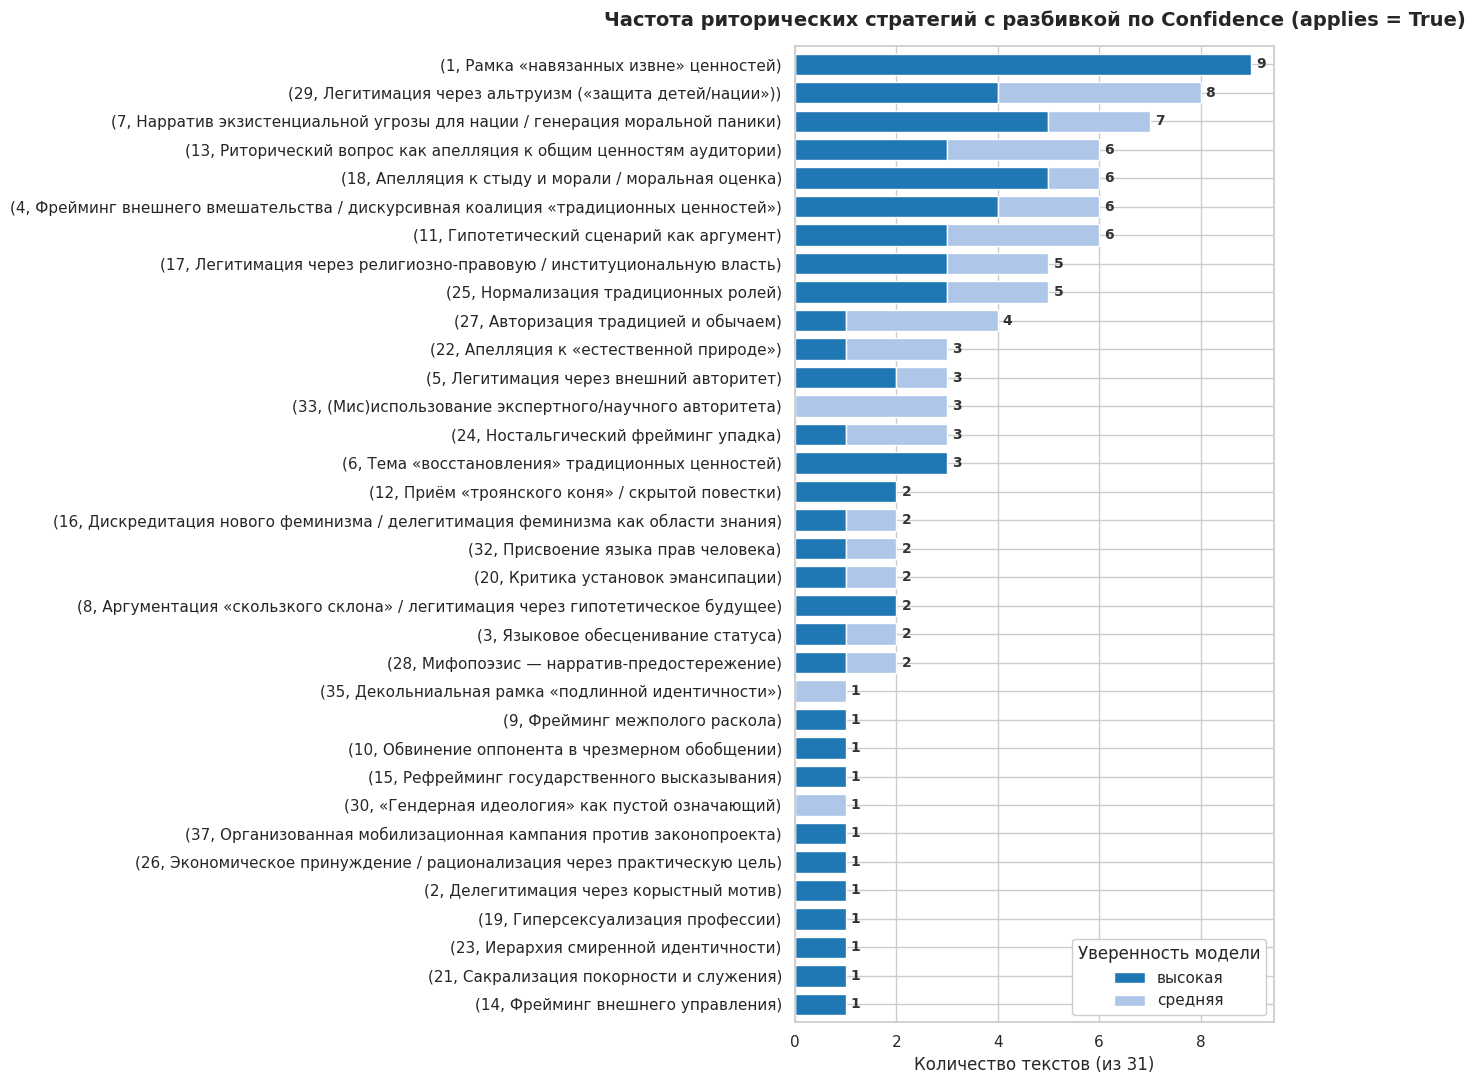

In [ ]:
# Настройка стиля
sns.set_theme(style="whitegrid")

# Подготовка данных: сортируем по возрастанию, чтобы топовые стратегии были наверху графика
df_chart = pivot_summary.sort_values(by='Всего', ascending=True)

# Динамически выбираем только существующие колонки уверенности
conf_columns = [col for col in ['высокая', 'средняя', 'низкая'] if col in df_chart.columns]

# Создаем один холст
fig, ax = plt.subplots(figsize=(13, 11))

# Строим накопительный горизонтальный столбчатый график
df_chart[conf_columns].plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#1f77b4', '#aec7e8', '#ffbb78'][:len(conf_columns)],
    width=0.75
)

# Оформление
ax.set_title('Частота риторических стратегий с разбивкой по Confidence (applies = True)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Количество текстов (из 31)', fontsize=12)
ax.set_ylabel('')
ax.legend(title='Уверенность модели', frameon=True, facecolor='white', framealpha=1)

# Добавляем значения итогового количества текстов рядом со столбцами
for i, (total, name) in enumerate(zip(df_chart['Всего'], df_chart.index)):
    ax.text(total + 0.1, i, str(int(total)), va='center', fontsize=10, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

## Аналитический вывод по результатам исследования <a name='вывод'></a>

Первичный анализ 31 текстового фрагмента публичных высказываний казахстанских акторов (2024–2026 гг.) по 37 риторическим кодам, выполненный моделью `claude-sonnet-5`, позволяет выделить базовую структуру и иерархию дискурса легитимации анти-гендерных позиций. Данные выводы носят промежуточный характер и подлежат последующей перекрестной проверке через Gemini API (расчет inter-rater reliability) и ручной экспертной валидации.

**Ядро дискурса: Геополитическая рамка и экзогенная угроза**

Доминирующей риторической стратегией в корпусе является *Рамка «навязанных извне» ценностей* (Код 1), зафиксированная в 9 из 31 текста с высокой уверенностью модели (confidence = высокая). В сочетании со стратегией *Фрейминга внешнего вмешательства* (Код 4), встречающейся в 6 текстах, это указывает на то, что ключевой вектор легитимации в Казахстане строится не на внутренней этической дискуссии, а на геополитической рамке. Гендерная повестка, права ЛГБТ и правозащитные инициативы репрезентируются спикерами не как предмет гражданского права, а как внешняя экспансия, угрожающая государственному и культурному суверенитету.

**Мобилизационный блок: Защита уязвимых и конструирование моральной паники**

Второй по значимости опорой дискурса выступает связка *Легитимации через альтруизм («защита детей/нации»)* (Код 29) в 8 текстах и *Нарратива экзистенциальной угрозы / генерации моральной паники* (Код 7) в 7 текстах.

Использование альтруистической рамки позволяет акторам смещать фокус с личной политической или религиозной позиции на «вынужденную защиту» подрастающего поколения.

Использование риторики экзистенциальной угрозы создает эффект неотложности действия: оппоненты позиционируются не просто как носители альтернативного мнения, а как сила, разрушающая основы выживания нации.

**Инструменты морально-этического давления и гипотетическое аргументирование**

Средний эшелон частоты формируют эмоциональные и аргументативные приемы:

*Апелляция к стыду и морали* (Код 18) в 6 текстах (преимущественно с высокой уверенностью).

*Риторические вопросы к общим ценностям аудитории* (Код 13) в 6 текстах.

*Гипотетические сценарии как аргумент* (Код 11) в 6 текстах.

Акторы активно прибегают к моделированию катастрофических сценариев будущего и апелляции к «здравому смыслу» аудитории, избегая рационально-правовой аргументации в пользу моральных суждений.

**Источники авторизации: Институт власти vs. Традиция**

Институциональные механизмы легитимации распределились следующим образом:

*Легитимация через религиозно-правовую / институциональную власть* (Код 17) в 5 текстах.

*Нормализация традиционных ролей* (Код 25) в 5 текстах.

*Авторизация традицией и обычаем* (Код 27) в 4 текстах (преимущественно со средней уверенностью).

Примечательно, что прямая ссылка на «обычаи предков» (Код 27) уступает по частоте суверенистским и морально-паническим фреймам. Традиция используется не как самостоятельный содержательный аргумент, а как фоновое обоснование для нормализации гендерных ролей и защиты от «внешнего влияния».

**Специфика локального контекста и периферийные коды**

Ряд специализированных категорий (включая *Декольниальную рамку «подлинной идентичности»* (Код 35), *Дискредитацию нового феминизма* (Код 16), *Присвоение языка прав человека* (Код 32) и *Организованные мобилизационные кампании* (Код 37)) представлены единичными или двойными случаями (1–2 текста). Это свидетельствует о том, что узкоакадемические или узкоспециализированные западные фреймы адаптируются казахстанскими акторами в ограниченном объеме, уступая место более универсальным эмоционально-геополитическим штампам.

**Промежуточный итог первого этапа**

Первичный этап автоматизированного анализа показал, что анти-гендерный дискурс публичных акторов Казахстана периода 2024–2026 годов представляет собой устойчивую дискурсивную коалицию. Несмотря на различие институциональных статусов спикеров (депутаты, религиозные деятели, инфлюенсеры), их риторика консолидируется вокруг трех главных опор: **защита суверенитета от внешнего навязывания, моральная паника вокруг защиты детей и нормализация традиционных ролей**.

Окончательное подтверждение этих гипотез и расчет надежности кодирования будут получены после проведения перекрестного анализа через Gemini и последующей ручной валидации результатов.